Projekt - Wykrywanie oszustw finansowych

Dane: Credi Card Fraud Detection https://www.kaggle.com/datasets/miadul/credit-card-fraud-detection-dataset

Cel biznesowy: Rozwój modeli do identyfikowania podejrzanych transakcji finansowych i zapobiegania oszustwom.

Stakeholderzy: Dział finansowy, ryzyka, bezpieczeństwa, klienci banku.

Nazwa teamu: Ocean's Four

1. Zaimportowanie bibliotek

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder)
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import (LogisticRegression, Ridge, Lasso, ElasticNet)
from sklearn.dummy import DummyClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, AdaBoostClassifier, IsolationForest)

from sklearn.feature_selection import (SelectKBest, mutual_info_classif, SelectFromModel, RFE)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.svm import SVC, LinearSVC, OneClassSVM

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.inspection import permutation_importance

import shap
import optuna
import joblib

from scipy.stats import randint
from scipy.stats import uniform

2. Wczytanie bazy danych

In [2]:
df = pd.read_csv("data/credit_card_fraud_10k.csv")

3. Wstępne sprawdzenie danych

In [3]:
df.shape

(10000, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 851.2 KB


In [5]:
df.head(20)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [6]:
if df.isnull().sum().sum() == 0:
    print("Brak wartości NULL w zbiorze danych.")
else:
    print("W zbiorze występują braki danych.")

Brak wartości NULL w zbiorze danych.


In [7]:
df = df.drop_duplicates()

In [8]:
df = df.drop(columns=["transaction_id"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   amount               10000 non-null  float64
 1   transaction_hour     10000 non-null  int64  
 2   merchant_category    10000 non-null  str    
 3   foreign_transaction  10000 non-null  int64  
 4   location_mismatch    10000 non-null  int64  
 5   device_trust_score   10000 non-null  int64  
 6   velocity_last_24h    10000 non-null  int64  
 7   cardholder_age       10000 non-null  int64  
 8   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 773.1 KB


In [9]:
df.describe()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


4. WIZUALIZACJE - graficzne pokazanie danych

4.1. Rozkład transakcji fraudowych i poprawnych

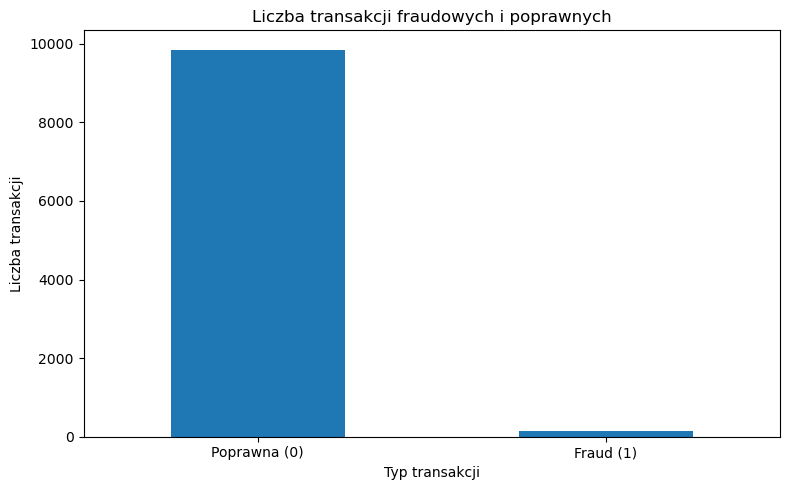

In [10]:
fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(8,5))
fraud_counts.plot(kind="bar")

plt.title("Liczba transakcji fraudowych i poprawnych")
plt.xlabel("Typ transakcji")
plt.ylabel("Liczba transakcji")

plt.xticks([0,1], ["Poprawna (0)", "Fraud (1)"], rotation=0)

plt.tight_layout()
plt.show()

4.2. Kwota transakcji a występowanie fraudu (Boxplot)

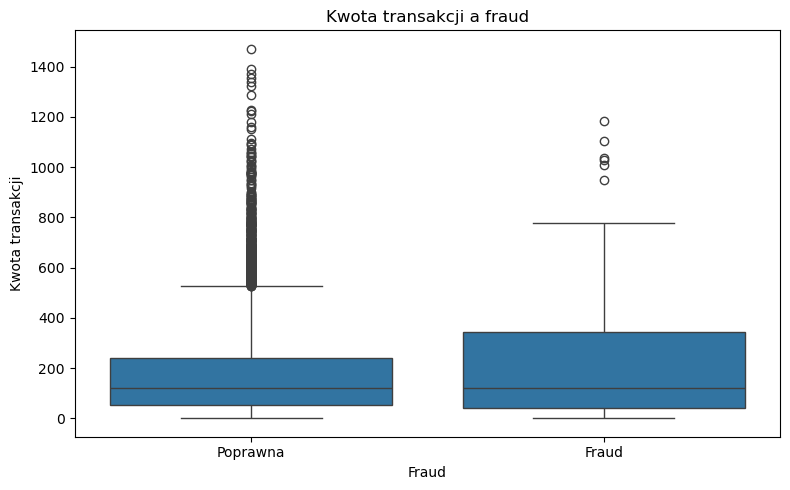

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount"
)

plt.title("Kwota transakcji a fraud")
plt.xlabel("Fraud")
plt.ylabel("Kwota transakcji")

plt.xticks([0,1], ["Poprawna", "Fraud"])

plt.tight_layout()
plt.show()

Interpretacja

Średnia wartość transakcji:

Poprawne: 175.33
Fraudowe: 216.18

Wnioski:

Fraudowe transakcje są przeciętnie droższe.
Sama kwota nie wystarczy do identyfikacji fraudu, ale może być istotną cechą modelu.

4.3. Fraud rate dla transakcji zagranicznych

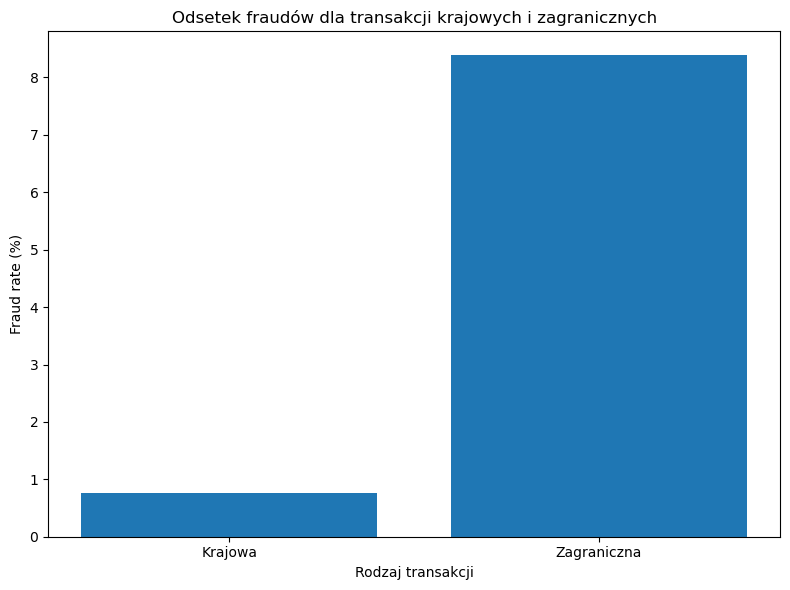

,foreign_transaction,is_fraud
0,0,0.007648
1,1,0.083845


In [14]:
fraud_rate = (
    df.groupby("foreign_transaction")["is_fraud"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,6))
plt.bar(
    ["Krajowa", "Zagraniczna"],
    fraud_rate["is_fraud"] * 100
)

plt.title("Odsetek fraudów dla transakcji krajowych i zagranicznych")
plt.xlabel("Rodzaj transakcji")
plt.ylabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

fraud_rate

Transakcje zagraniczne są ponad 10 razy bardziej narażone na fraud niż krajowe. Jest to jedna z najsilniejszych zależności w zbiorze.

4.4. Heatmapa korelacji zmiennych numerycznych

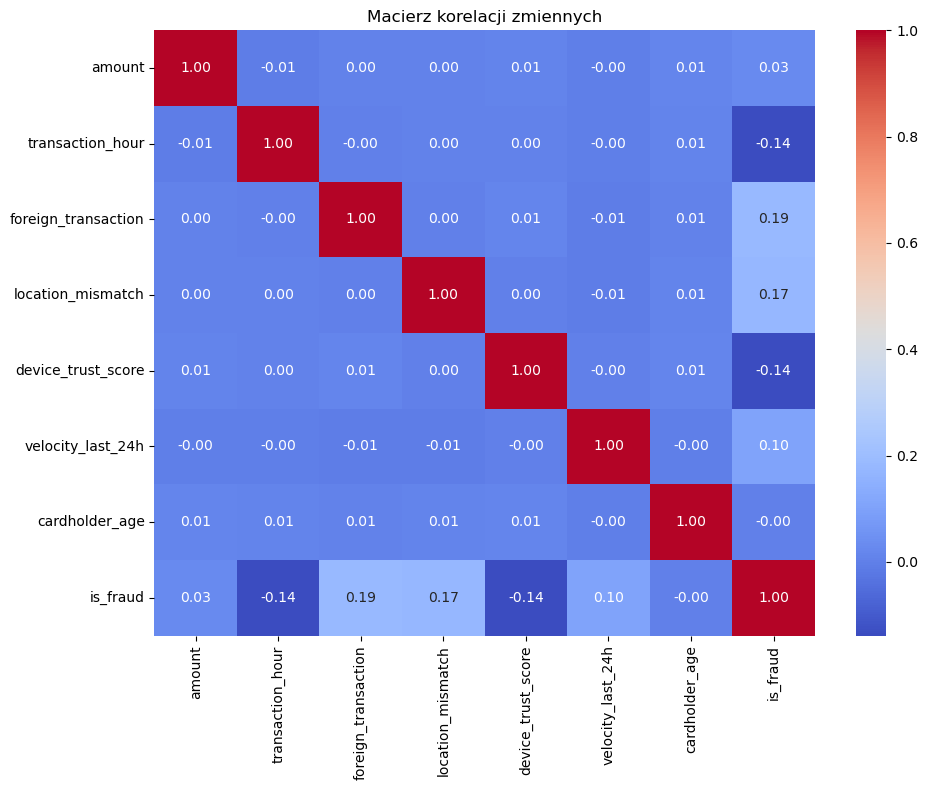

In [15]:
numeric_cols = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age",
    "is_fraud"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Macierz korelacji zmiennych")

plt.tight_layout()
plt.show()

Wnioski:

Fraudy częściej pojawiają się:
przy dużej liczbie transakcji w ciągu 24h,
przy niezgodności lokalizacji,
przy transakcjach zagranicznych.

Fraudy rzadziej występują dla urządzeń o wysokim poziomie zaufania.